<a href="https://colab.research.google.com/github/Fano-Rdz/178584/blob/main/manuscrito_178584.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de manuscrito
Aplicar técnicas de minería de datos y aprendizaje automático para entrenar y evaluar distintos modelos de clasificación usando el dataset Digits (8×8). Posteriormente, se evaluará su desempeño clasificando dígitos manuscritos creados por el estudiante.

## Carga del dataset

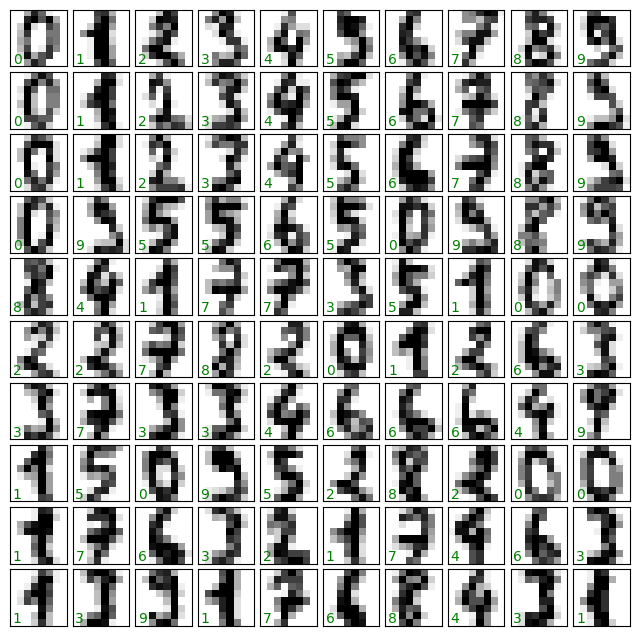

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

## Modelo KNN

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 1437
Muestras de prueba: 360


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión del modelo KNN: {accuracy_knn:.4f}")

Precisión del modelo KNN: 0.9861


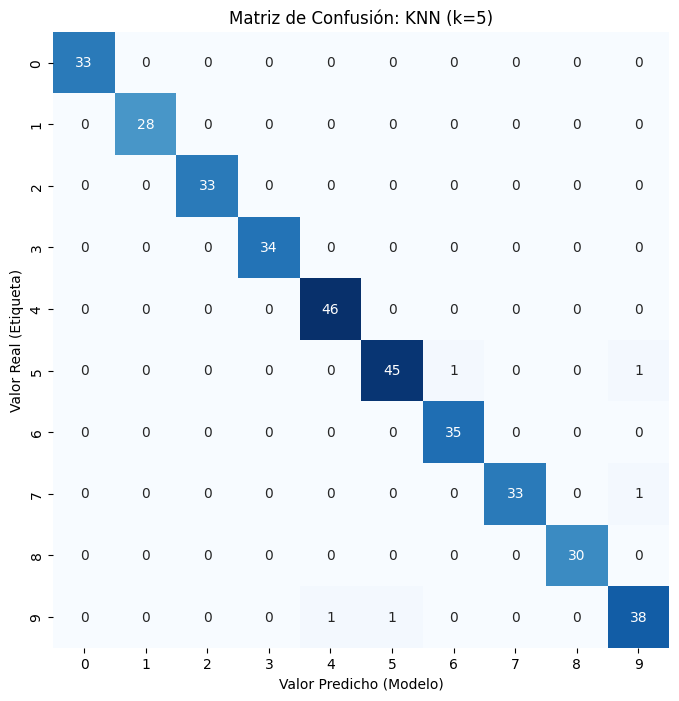

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generar la matriz
mat = confusion_matrix(y_test, y_pred_knn)

# 2. Configurar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)

# 3. Etiquetas
plt.xlabel('Valor Predicho (Modelo)')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión: KNN (k=5)')
plt.show()

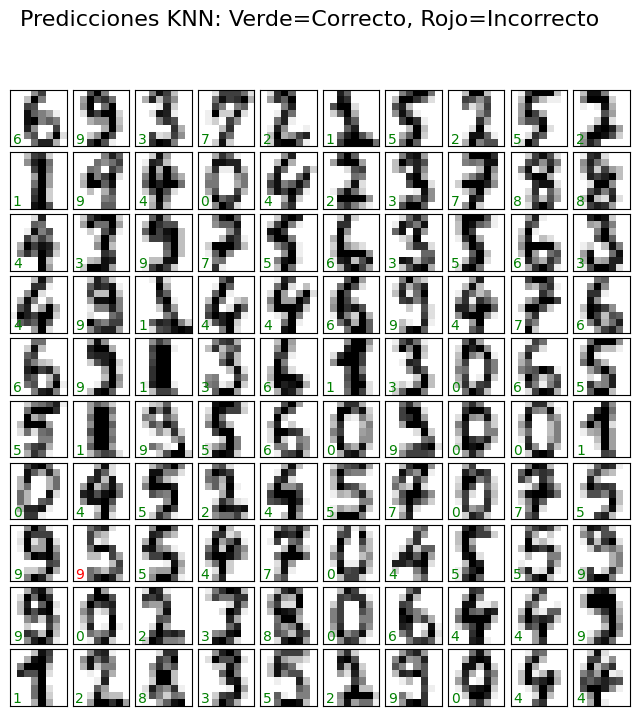

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

test_images = X_test.reshape(-1, 8, 8)

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='binary', interpolation='nearest')

    is_correct = (y_test[i] == y_pred_knn[i])
    label_color = 'green' if is_correct else 'red'

    ax.text(0.05, 0.05, str(y_pred_knn[i]),
            transform=ax.transAxes,
            color=label_color)

plt.suptitle('Predicciones KNN: Verde=Correcto, Rojo=Incorrecto', fontsize=16)
plt.show()

In [ ]:
from google.colab import files
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()



Saving cuatro.png to cuatro.png
Saving dos.png to dos.png
Saving uno.png to uno.png


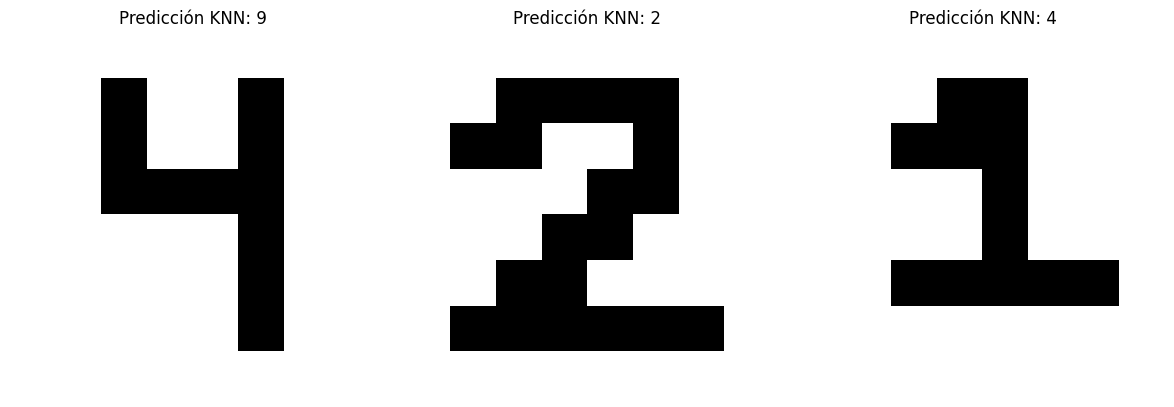

In [ ]:
def procesar_imagen(data_imagen):
    img = Image.open(io.BytesIO(data_imagen)).convert('L')
    img_8x8 = img.resize((8, 8), Image.Resampling.LANCZOS)

    img_array = np.array(img_8x8, dtype=np.float32)
    img_final = (1.0 - (img_array / 255.0)) * 16.0
    return img_final

imagenes_procesadas = []
nombres = []

for nombre_archivo in uploaded.keys():
    img_8x8 = procesar_imagen(uploaded[nombre_archivo])
    imagenes_procesadas.append(img_8x8)
    nombres.append(nombre_archivo)

plt.figure(figsize=(12, 4))

for i in range(len(imagenes_procesadas)):
    dato_plano = imagenes_procesadas[i].reshape(1, -1)

    prediccion = knn_model.predict(dato_plano)[0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(imagenes_procesadas[i], cmap='gray_r')
    plt.title(f"Predicción KNN: {prediccion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Modelo SVC

Exactitud de SVM: 0.9861


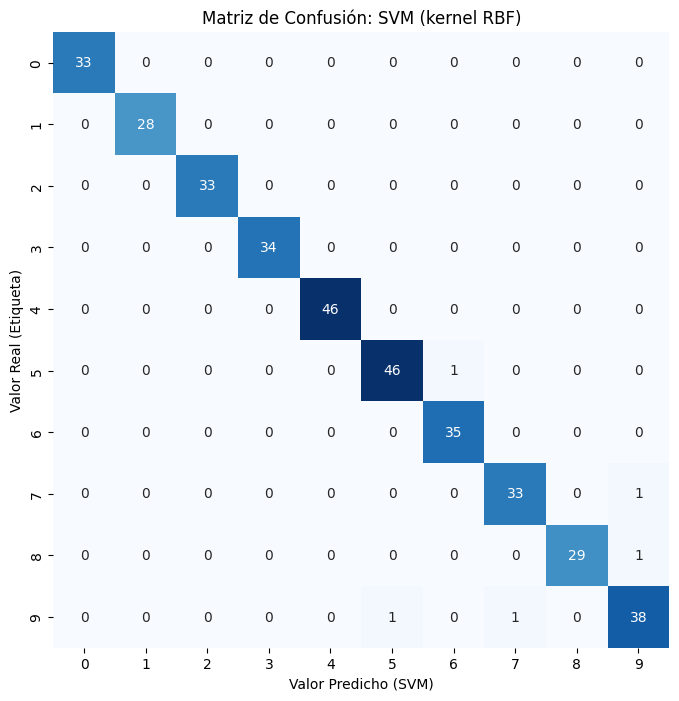

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(f"Exactitud de SVM: {accuracy_score(y_test, y_pred_svm):.4f}")

mat_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(mat_svm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('Valor Predicho (SVM)')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión: SVM (kernel RBF)')
plt.show()

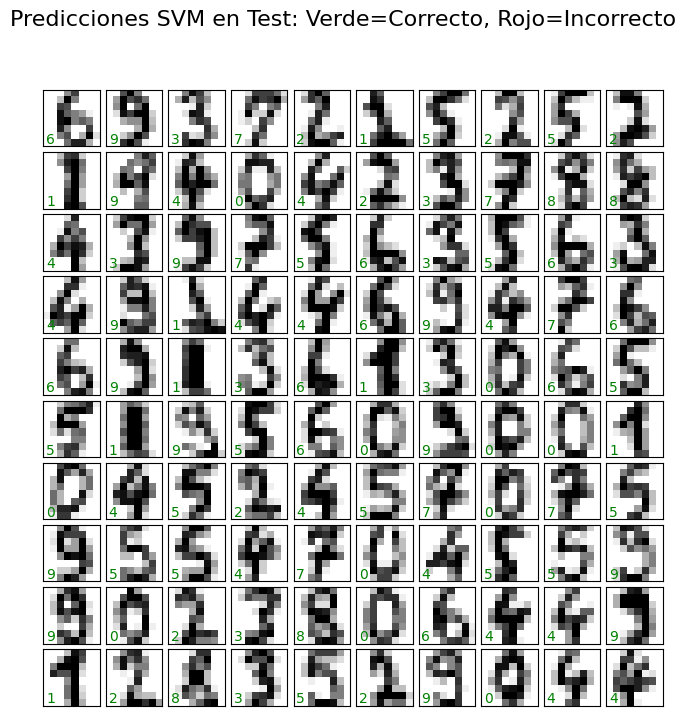

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='binary', interpolation='nearest')

    is_correct = (y_test[i] == y_pred_svm[i])
    label_color = 'green' if is_correct else 'red'

    ax.text(0.05, 0.05, str(y_pred_svm[i]),
            transform=ax.transAxes,
            color=label_color)

plt.suptitle('Predicciones SVM en Test: Verde=Correcto, Rojo=Incorrecto', fontsize=16)
plt.show()

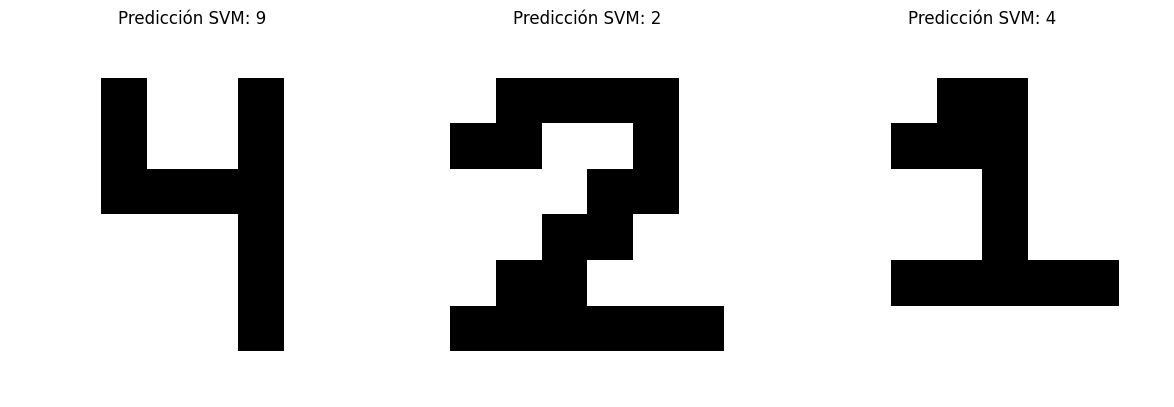

In [ ]:
imagenes_procesadas = []
nombres = []

for nombre_archivo in uploaded.keys():
    img_8x8 = procesar_imagen(uploaded[nombre_archivo])
    imagenes_procesadas.append(img_8x8)
    nombres.append(nombre_archivo)

plt.figure(figsize=(12, 4))

for i in range(len(imagenes_procesadas)):
    dato_plano = imagenes_procesadas[i].reshape(1, -1)

    prediccion = svm_model.predict(dato_plano)[0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(imagenes_procesadas[i], cmap='gray_r')
    plt.title(f"Predicción SVM: {prediccion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Modelo Random Forest

Exactitud de Random Forest: 0.9722


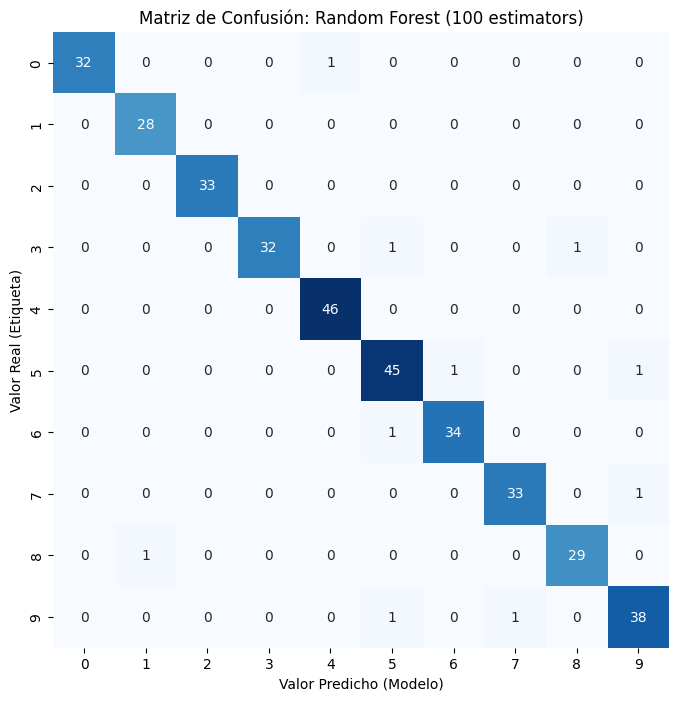

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Exactitud de Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")

mat_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(mat_rf, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)

plt.xlabel('Valor Predicho (Modelo)')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión: Random Forest (100 estimators)')
plt.show()

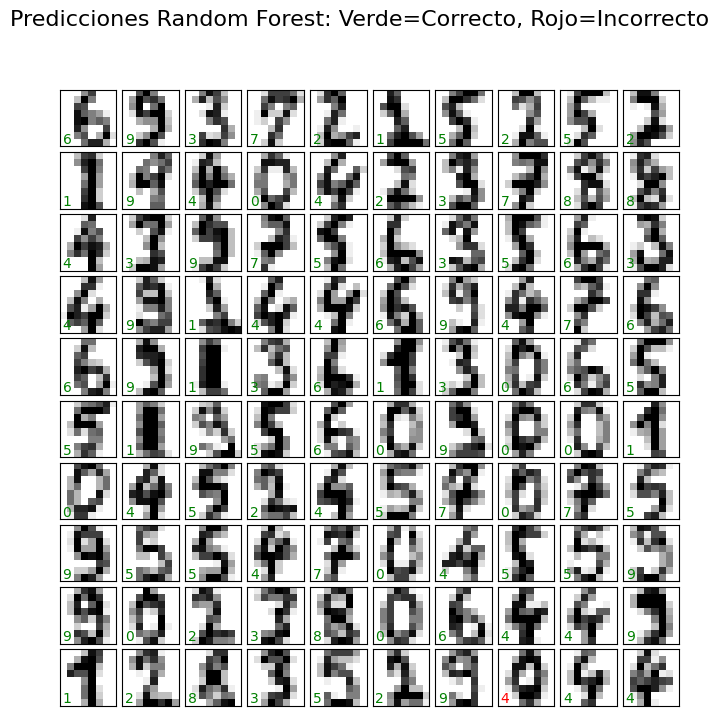

In [ ]:
test_images = X_test.reshape(-1, 8, 8)

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='binary', interpolation='nearest')

    is_correct = (y_test[i] == y_pred_rf[i])
    label_color = 'green' if is_correct else 'red'

    ax.text(0.05, 0.05, str(y_pred_rf[i]),
            transform=ax.transAxes,
            color=label_color)

plt.suptitle('Predicciones Random Forest: Verde=Correcto, Rojo=Incorrecto', fontsize=16)
plt.show()

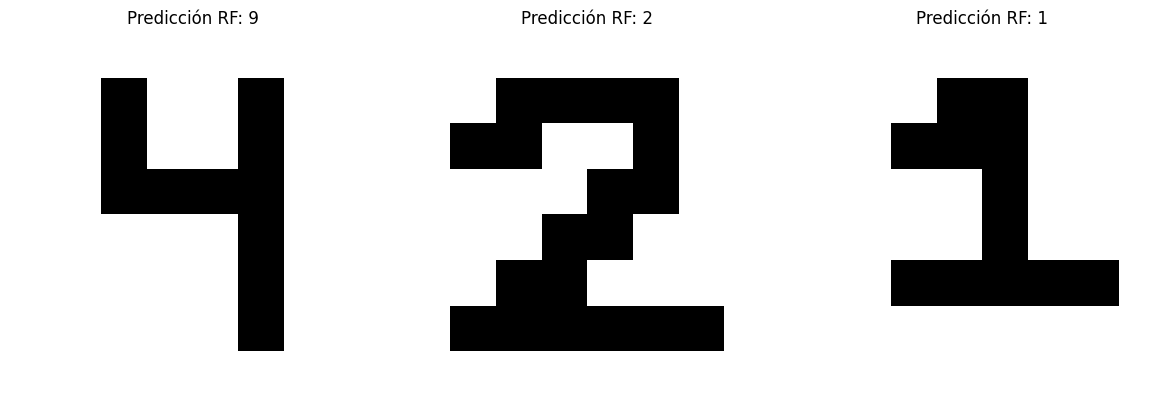

In [ ]:
plt.figure(figsize=(12, 4))

for i in range(len(imagenes_procesadas)):
    dato_plano = imagenes_procesadas[i].reshape(1, -1)

    prediccion = rf_model.predict(dato_plano)[0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(imagenes_procesadas[i], cmap='gray_r')
    plt.title(f"Predicción RF: {prediccion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusion
El modelo con mejores resultados prácticos fue Random Forest. Aunque modelos como SVM alcanzaron una exactitud superior al 98% en el conjunto de prueba estándar, Random Forest demostró mayor capacidad de generalización al clasificar correctamente 2 de las 3 imágenes externas creadas manualmente. Esto sugiere que su estructura de ensamble (múltiples árboles de decisión) es más robusta para procesar datos que no pertenecen estrictamente al dataset original.

El reto principal fue la homologación de datos. Las imágenes digitales cargadas (PNG) operan en una escala de 0-255, mientras que el dataset load_digits utiliza una escala de 0-16. Fue crítico realizar un preprocesamiento preciso para invertir los colores (fondo claro a oscuro) y redimensionar las imágenes a 8×8 píxeles sin perder la esencia del trazo, lo cual es difícil en una resolución tan baja.

Los errores en KNN y SVM ocurrieron principalmente por la sensibilidad de estos algoritmos a la posición y grosor del trazo. En una matriz de solo 64 píxeles, variaciones mínimas en la inclinación de un número pueden confundir al modelo (por ejemplo, confundir un "4" con un "1"). Random Forest mitigó esto mejor gracias a su capacidad de promediar predicciones, siendo menos propenso a fallar por "ruido" visual o trazos ligeramente diferentes a los del entrenamiento.